#  Brain Tumor MRI — Grad-CAM Visualisations


---

A model that achieves 95% accuracy is useful. A model that can *show you why* it made a decision is trustworthy especially in a medical context where a prediction without an explanation is rarely enough.

Grad-CAM (**Gradient-weighted Class Activation Mapping**) bridges that gap. Instead of treating the model as a black box, it looks inside the final convolutional layer and asks: *which regions of this MRI scan most influenced the prediction?* The answer is visualised as a heatmap overlaid directly on the original scan.

---

### How Grad-CAM Works — Step by Step

| Step | What Happens |
|------|-------------|
| 1. **Forward pass** | Image passes through the network — feature maps captured at the last conv layer |
| 2. **Backward pass** | Gradient of the predicted class score flows back to that layer |
| 3. **Weight each channel** | Gradients are globally averaged — one importance weight per feature map channel |
| 4. **Weighted sum** | Feature maps are combined using those weights → raw heatmap |
| 5. **ReLU** | Negative values removed — only regions that *increased* the class score are kept |
| 6. **Resize & overlay** | Heatmap resized to 224×224 and blended onto the original MRI scan |

The result is a colour-coded map where **red and yellow regions** indicate where the model focused most, and **blue regions** indicate areas it largely ignored.

---

### What We Are Looking For

A well-trained model should focus on the **tumour region itself** not the skull, not the background, not random noise. If the heatmap highlights the correct anatomical region, it gives us confidence that the model has learned medically meaningful features rather than spurious correlations.

We examine both:
-  **Correct predictions**  does the heatmap focus on the right region?
- **Incorrect predictions**  where did the model look when it got it wrong?

---

> **Prerequisite:** Ensure `train.ipynb` and `model_development.ipynb` have been run first and all model weights are saved in the `saved_models/` directory before executing this notebook.

---
## Step 2 · Load Config & Rebuild Test DataLoader

In [5]:
import json, random, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as mpl_cm
import seaborn as sns
import cv2
from PIL import Image
from tqdm import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


In [6]:
with open('config.json') as f:
    cfg = json.load(f)

CLASS_NAMES   = cfg['class_names']
NUM_CLASSES   = cfg['num_classes']
IMG_SIZE      = cfg['img_size']
BATCH_SIZE    = cfg['batch_size']
IMAGENET_MEAN = cfg['imagenet_mean']
IMAGENET_STD  = cfg['imagenet_std']
COLORS        = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']
SAVE_DIR      = Path('saved_models')

# ── Same path as train.ipynb ───────────────────────────────────────────────────
DATA_ROOT = Path(r"C:\Users\golla\Downloads\Brain Tumor Classification from MRI Images\archive (2)")
TEST_DIR  = DATA_ROOT / 'Testing'

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

test_dataset = datasets.ImageFolder(str(TEST_DIR), transform=test_transforms)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                           shuffle=False, num_workers=0)

print(f"Test images : {len(test_dataset)}")
print(f"Classes     : {test_dataset.class_to_idx}")

Test images : 1600
Classes     : {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


---
## Step 3 · Load Best Model (EfficientNet-B0)

In [9]:
def build_efficientnet_b0(num_classes: int = 4) -> nn.Module:
    model = models.efficientnet_b0(weights=None)
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(model.classifier[1].in_features, num_classes),
    )
    return model


model = build_efficientnet_b0(NUM_CLASSES).to(DEVICE)

weights_path = SAVE_DIR / 'EfficientNet_B0_best.pth'
if weights_path.exists():
    model.load_state_dict(torch.load(weights_path, map_location=DEVICE))
    print(f"Loaded weights: {weights_path}")
else:
    print(f"WARNING: {weights_path} not found.")
    print("Make sure you ran model_development.ipynb first.")
    print("Continuing with random weights (for demonstration only).")

model.eval()
print("Model ready.")

Loaded weights: saved_models\EfficientNet_B0_best.pth
Model ready.


---
## Step 4 · Grad-CAM Class

In [10]:
class GradCAM:
    """
    Grad-CAM using PyTorch forward + backward hooks.

    Parameters
    ----------
    model        : nn.Module — the trained model
    target_layer : nn.Module — the convolutional layer to hook

    Usage
    -----
    gradcam = GradCAM(model, model.features[-1][0])
    cam, pred, probs = gradcam.generate(image_tensor)   # (1, 3, 224, 224)
    """

    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model       = model
        self.activations = None
        self.gradients   = None

        # Forward hook: saves the output (feature maps) of the target layer
        target_layer.register_forward_hook(
            lambda m, inp, out: setattr(self, 'activations', out.detach()))

        # Backward hook: saves the gradients flowing into the target layer
        target_layer.register_full_backward_hook(
            lambda m, grad_in, grad_out: setattr(self, 'gradients', grad_out[0].detach()))

    def generate(self, input_tensor: torch.Tensor,
                 class_idx: int = None):
        """
        Generate a Grad-CAM heatmap.

        Parameters
        ----------
        input_tensor : (1, 3, H, W) normalised tensor on CPU
        class_idx    : target class — None means use predicted class

        Returns
        -------
        cam        : (H, W) numpy array in [0, 1]
        pred_class : int — the predicted class index
        probs      : (num_classes,) numpy array — softmax probabilities
        """
        self.model.eval()
        inp = input_tensor.to(DEVICE).requires_grad_(True)

        # ── Forward ────────────────────────────────────────────────────────────
        output     = self.model(inp)                    # (1, num_classes)
        pred_class = output.argmax(1).item()
        if class_idx is None:
            class_idx = pred_class

        # ── Backward ───────────────────────────────────────────────────────────
        self.model.zero_grad()
        output[0, class_idx].backward()

        # ── Compute CAM ────────────────────────────────────────────────────────
        # Importance weight for each channel = global average of its gradients
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # (1, C, 1, 1)

        # Weighted sum of activation maps
        cam = (weights * self.activations).sum(dim=1, keepdim=True)  # (1,1,H',W')
        cam = torch.relu(cam)                           # keep positive contributions only
        cam = cam.squeeze().cpu().numpy()               # (H', W')

        # Normalise to [0, 1] and upscale to input resolution
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))

        probs = torch.softmax(output, dim=1)[0].detach().cpu().numpy()
        return cam, pred_class, probs


def denormalize(tensor: torch.Tensor) -> np.ndarray:
    """Reverse ImageNet normalisation → (H, W, 3) float32 in [0, 1]."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return torch.clamp(tensor.cpu() * std + mean, 0, 1).permute(1, 2, 0).numpy()


def overlay_cam(img_np: np.ndarray, cam: np.ndarray,
                alpha: float = 0.45) -> np.ndarray:
    """Blend a jet-coloured heatmap over the original image."""
    heatmap = mpl_cm.jet(cam)[:, :, :3]            # (H, W, 3) RGB
    return np.clip(alpha * heatmap + (1 - alpha) * img_np, 0, 1)


# ── Attach Grad-CAM to the last conv block of EfficientNet-B0 ────────────────
target_layer = model.features[-1][0]
gradcam      = GradCAM(model, target_layer)
print(f"Grad-CAM attached to: {target_layer.__class__.__name__}")

Grad-CAM attached to: Conv2d


---
## Step 5 · Collect Correct & Incorrect Examples per Class

In [11]:
def collect_examples(model: nn.Module,
                     dataset: datasets.ImageFolder,
                     n_correct: int = 2,
                     n_wrong:   int = 2) -> dict:
    """
    Find n_correct correctly classified and n_wrong misclassified examples
    for every class.

    Returns
    -------
    examples : dict  {class_idx: {'correct': [...], 'wrong': [...]}}
               Each entry is {'tensor': img_tensor, 'true': int, 'pred': int}
    """
    examples = {i: {'correct': [], 'wrong': []} for i in range(NUM_CLASSES)}
    model.eval()

    with torch.no_grad():
        for img, label in dataset:
            pred  = model(img.unsqueeze(0).to(DEVICE)).argmax(1).item()
            entry = {'tensor': img, 'true': label, 'pred': pred}
            bucket = 'correct' if pred == label else 'wrong'
            target_n = n_correct if bucket == 'correct' else n_wrong

            if len(examples[label][bucket]) < target_n:
                examples[label][bucket].append(entry)

            # Stop once all classes have enough of both types
            if all(len(v['correct']) >= n_correct and len(v['wrong']) >= n_wrong
                   for v in examples.values()):
                break

    print("Examples collected:")
    for i, name in enumerate(CLASS_NAMES):
        nc = len(examples[i]['correct'])
        nw = len(examples[i]['wrong'])
        print(f"  {name:<12} : {nc} correct, {nw} wrong")
    return examples


examples = collect_examples(model, test_dataset, n_correct=2, n_wrong=2)
print("Done.")

Examples collected:
  glioma       : 2 correct, 2 wrong
  meningioma   : 2 correct, 2 wrong
  notumor      : 2 correct, 0 wrong
  pituitary    : 2 correct, 0 wrong
Done.


---
## Step 6 · Grad-CAM Grid: All Classes × Correct + Incorrect

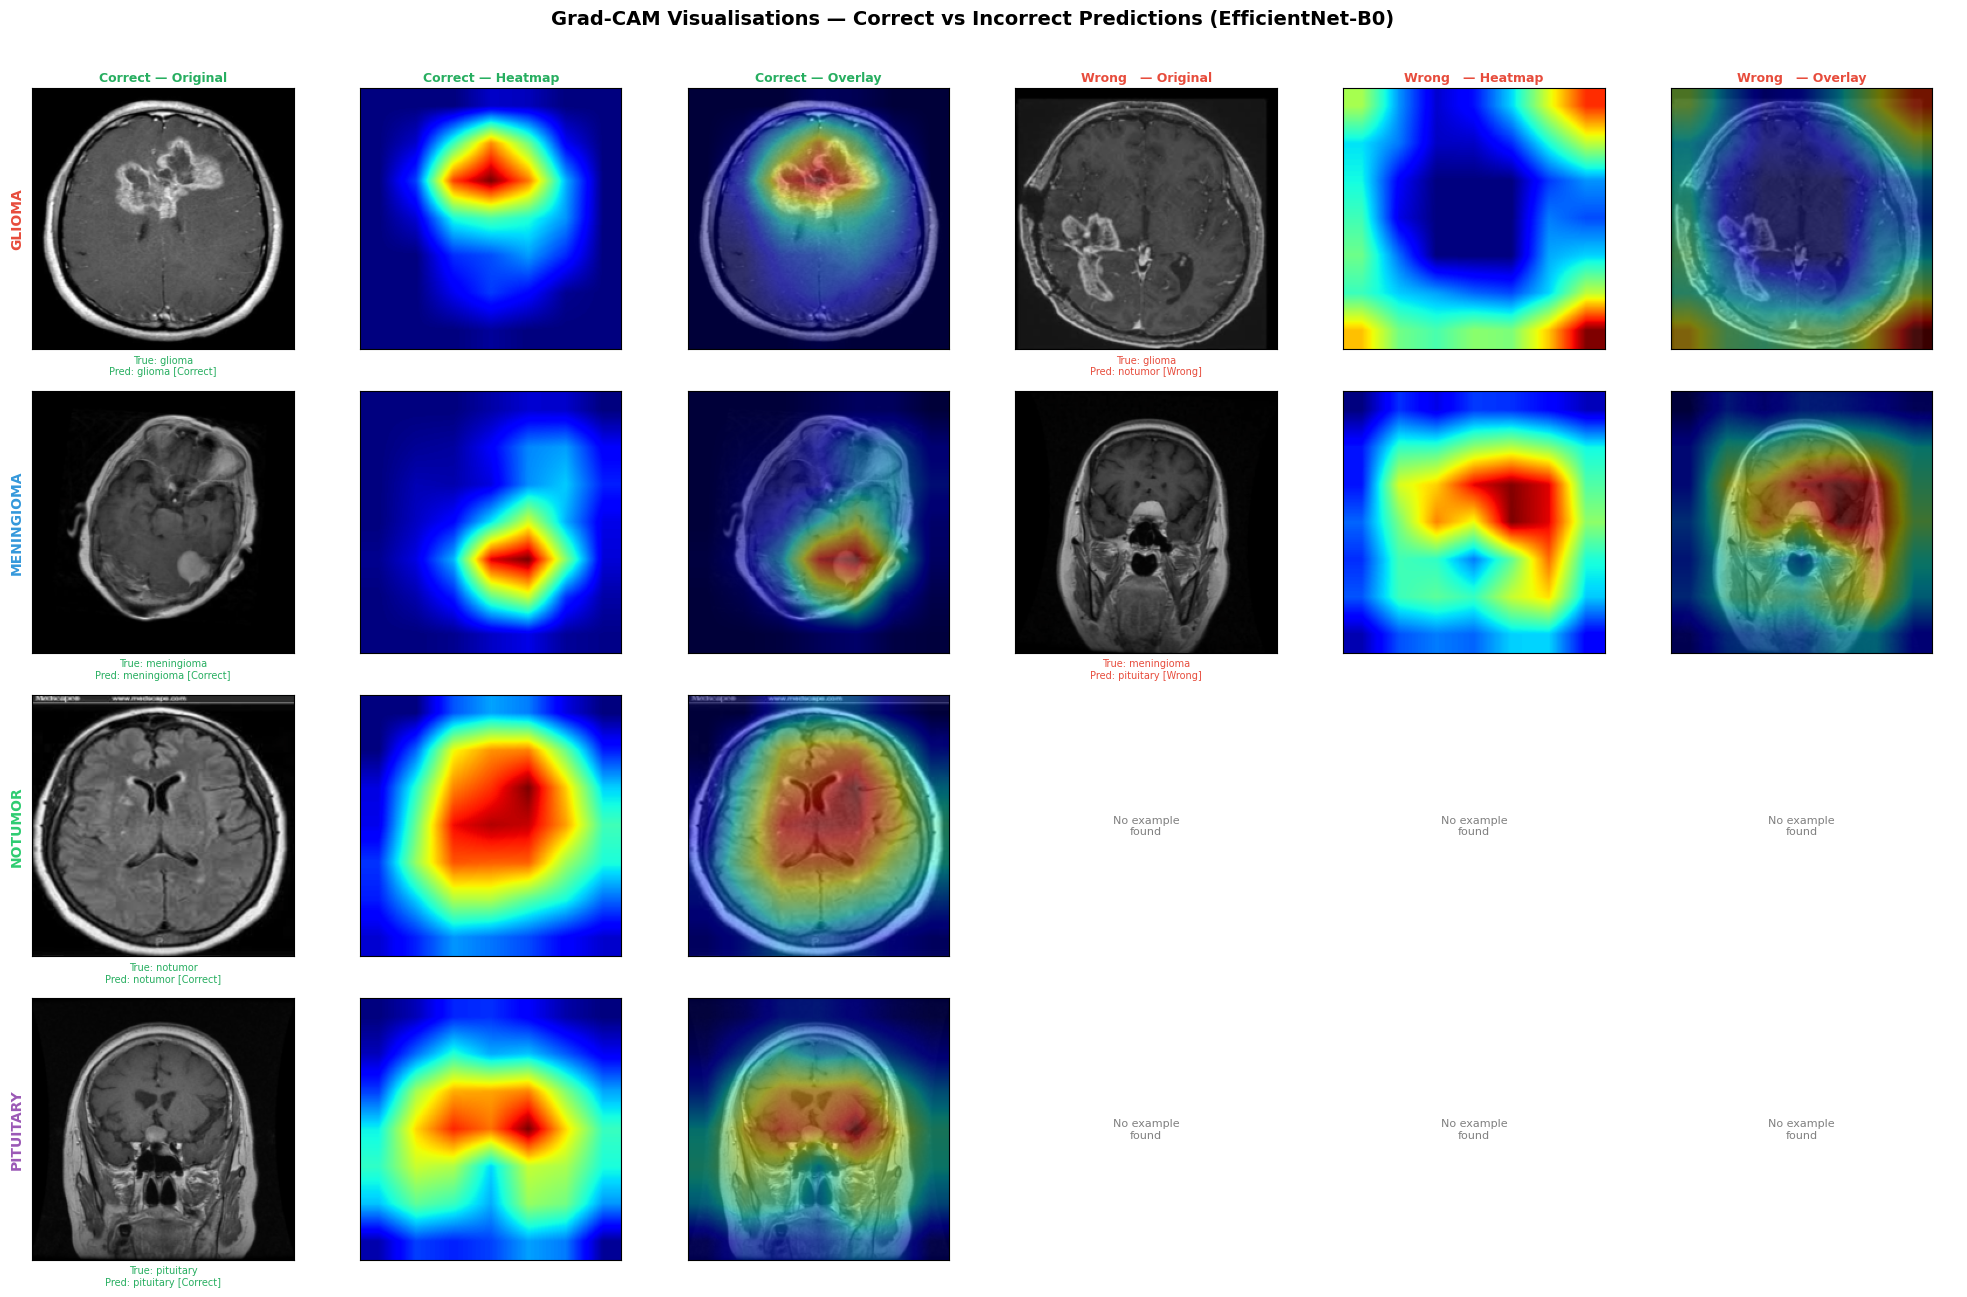

Saved: gradcam_grid.png


In [12]:
fig, axes = plt.subplots(NUM_CLASSES, 6, figsize=(20, NUM_CLASSES * 3.2))

# Column headers
col_titles = [
    'Correct — Original', 'Correct — Heatmap', 'Correct — Overlay',
    'Wrong   — Original', 'Wrong   — Heatmap', 'Wrong   — Overlay',
]
col_colors = ['#27AE60'] * 3 + ['#E74C3C'] * 3

for col, (title, clr) in enumerate(zip(col_titles, col_colors)):
    axes[0, col].set_title(title, fontsize=9, fontweight='bold',
                            color=clr, pad=5)

for row, cls_idx in enumerate(range(NUM_CLASSES)):
    # Row label on the left
    axes[row, 0].set_ylabel(
        CLASS_NAMES[cls_idx].upper(), fontsize=10, fontweight='bold',
        color=COLORS[cls_idx], rotation=90, labelpad=6)

    # Pick one correct and one wrong example (fall back to correct if no wrong found)
    correct_ex = examples[cls_idx]['correct']
    wrong_ex   = examples[cls_idx]['wrong']
    pair = [
        (correct_ex[0] if correct_ex else None, True),
        (wrong_ex[0]   if wrong_ex   else None, False),
    ]

    for item_idx, (entry, is_correct) in enumerate(pair):
        base = item_idx * 3

        if entry is None:
            for c in range(3):
                axes[row, base + c].axis('off')
                axes[row, base + c].set_facecolor('#f0f0f0')
                axes[row, base + c].text(0.5, 0.5, 'No example\nfound',
                    ha='center', va='center', transform=axes[row, base + c].transAxes,
                    fontsize=8, color='gray')
            continue

        img_np  = denormalize(entry['tensor'])
        cam, pred_cls, probs = gradcam.generate(entry['tensor'].unsqueeze(0))
        overlay = overlay_cam(img_np, cam)

        true_name = CLASS_NAMES[entry['true']]
        pred_name = CLASS_NAMES[pred_cls]
        clr       = '#27AE60' if is_correct else '#E74C3C'
        status    = 'Correct' if is_correct else 'Wrong'

        # Col 0 — original image
        axes[row, base].imshow(img_np)
        axes[row, base].set_xlabel(
            f'True: {true_name}\nPred: {pred_name} [{status}]',
            fontsize=7, color=clr)

        # Col 1 — heatmap
        axes[row, base + 1].imshow(cam, cmap='jet')

        # Col 2 — overlay
        axes[row, base + 2].imshow(overlay)

        for c in range(3):
            axes[row, base + c].set_xticks([])
            axes[row, base + c].set_yticks([])

fig.suptitle(
    'Grad-CAM Visualisations — Correct vs Incorrect Predictions (EfficientNet-B0)',
    fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('gradcam_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: gradcam_grid.png')

---
## Step 7 · Detailed Single-Image Panel with Confidence Bars

Correct example — class: glioma


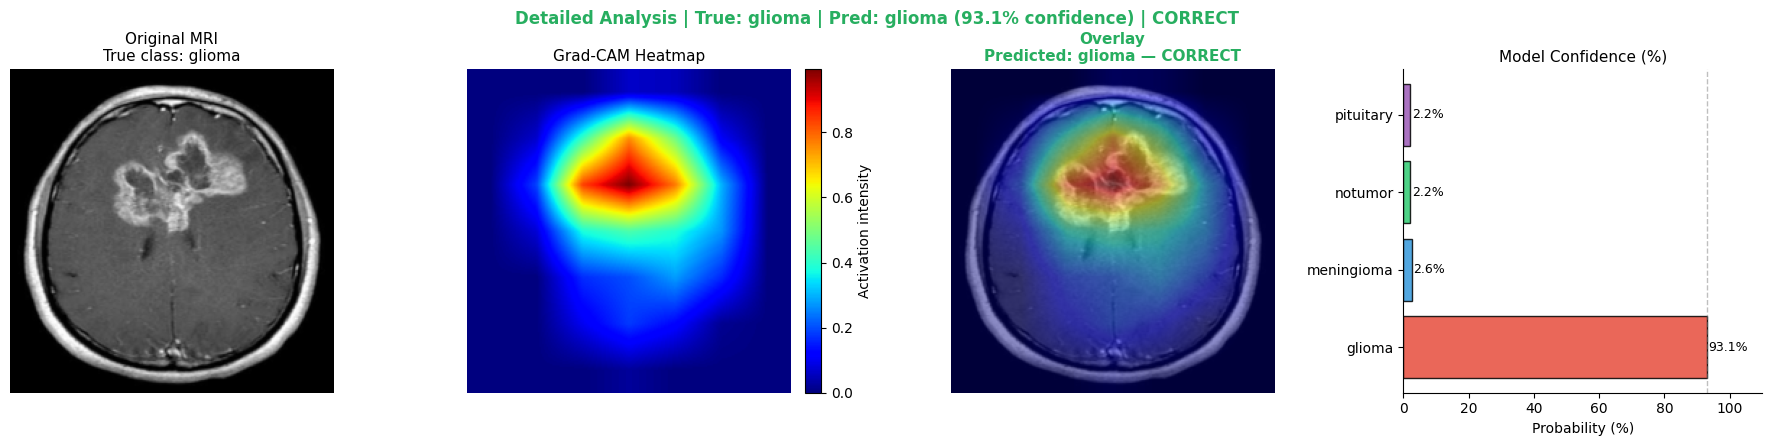

Saved: gradcam_correct.png

Incorrect example — class: glioma


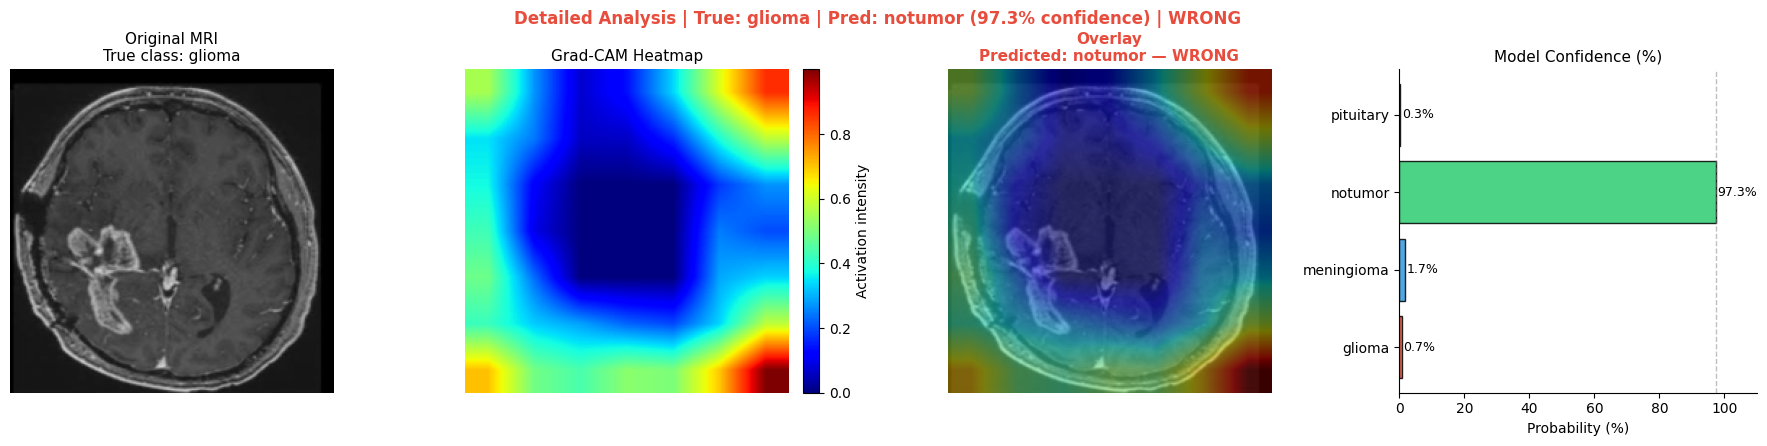

Saved: gradcam_wrong.png


In [13]:
def analyze_image(entry: dict, save_name: str = 'gradcam_detail.png'):
    """
    4-panel view for one image:
    [Original] | [Heatmap + colorbar] | [Overlay + verdict] | [Confidence bars]
    """
    img_np  = denormalize(entry['tensor'])
    cam, pred_cls, probs = gradcam.generate(entry['tensor'].unsqueeze(0))
    overlay = overlay_cam(img_np, cam)

    true_name = CLASS_NAMES[entry['true']]
    pred_name = CLASS_NAMES[pred_cls]
    correct   = (pred_cls == entry['true'])
    status    = 'CORRECT' if correct else 'WRONG'
    clr       = '#27AE60' if correct else '#E74C3C'

    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

    # Panel 1 — original
    axes[0].imshow(img_np)
    axes[0].set_title(f'Original MRI\nTrue class: {true_name}', fontsize=11)
    axes[0].axis('off')

    # Panel 2 — heatmap
    im = axes[1].imshow(cam, cmap='jet')
    axes[1].set_title('Grad-CAM Heatmap', fontsize=11)
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04,
                 label='Activation intensity')

    # Panel 3 — overlay
    axes[2].imshow(overlay)
    axes[2].set_title(f'Overlay\nPredicted: {pred_name} — {status}',
                      fontsize=11, color=clr, fontweight='bold')
    axes[2].axis('off')

    # Panel 4 — confidence bars
    bars = axes[3].barh(CLASS_NAMES, probs * 100,
                        color=COLORS, edgecolor='black', alpha=0.85)
    axes[3].set_title('Model Confidence (%)', fontsize=11)
    axes[3].set_xlim(0, 110)
    axes[3].set_xlabel('Probability (%)')
    for bar, prob in zip(bars, probs):
        axes[3].text(bar.get_width() + 0.5,
                     bar.get_y() + bar.get_height() / 2,
                     f'{prob*100:.1f}%', va='center', fontsize=9)
    # Mark predicted class
    axes[3].axvline(x=probs[pred_cls] * 100,
                    color='gray', linestyle='--', alpha=0.5, linewidth=1)
    axes[3].spines[['top', 'right']].set_visible(False)

    plt.suptitle(
        f'Detailed Analysis | True: {true_name} | Pred: {pred_name} '
        f'({probs[pred_cls]*100:.1f}% confidence) | {status}',
        fontsize=12, fontweight='bold', color=clr)
    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_name}')


# ── Show one correct prediction ───────────────────────────────────────────────
for cls_idx in range(NUM_CLASSES):
    if examples[cls_idx]['correct']:
        print(f"Correct example — class: {CLASS_NAMES[cls_idx]}")
        analyze_image(examples[cls_idx]['correct'][0], 'gradcam_correct.png')
        break

# ── Show one incorrect prediction ────────────────────────────────────────────
for cls_idx in range(NUM_CLASSES):
    if examples[cls_idx]['wrong']:
        print(f"\nIncorrect example — class: {CLASS_NAMES[cls_idx]}")
        analyze_image(examples[cls_idx]['wrong'][0], 'gradcam_wrong.png')
        break

---
## Step 8 · Per-Class Focus Map (What the Model Focuses On)

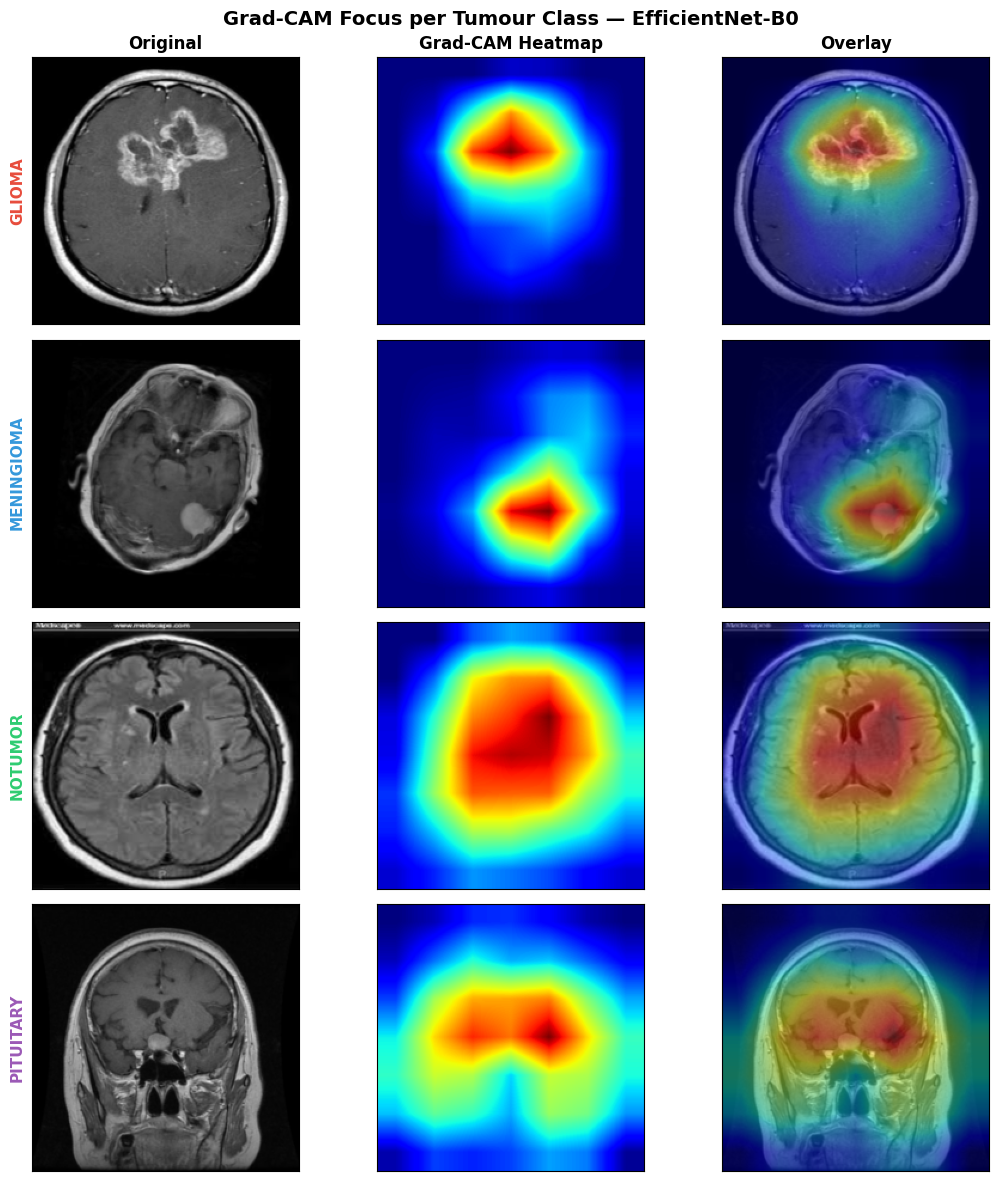

Saved: gradcam_per_class.png


In [14]:
fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(11, NUM_CLASSES * 3))
col_titles = ['Original', 'Grad-CAM Heatmap', 'Overlay']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=12, fontweight='bold', pad=6)

for row, cls_idx in enumerate(range(NUM_CLASSES)):
    entry = (examples[cls_idx]['correct'] or examples[cls_idx]['wrong'])
    if not entry:
        for c in range(3):
            axes[row, c].axis('off')
        continue

    entry   = entry[0]
    img_np  = denormalize(entry['tensor'])
    cam, pred_cls, probs = gradcam.generate(entry['tensor'].unsqueeze(0))
    overlay = overlay_cam(img_np, cam)

    axes[row, 0].imshow(img_np)
    axes[row, 1].imshow(cam, cmap='jet')
    axes[row, 2].imshow(overlay)

    for c in range(3):
        axes[row, c].set_xticks([]); axes[row, c].set_yticks([])

    axes[row, 0].set_ylabel(CLASS_NAMES[cls_idx].upper(), fontsize=11,
                             fontweight='bold', color=COLORS[cls_idx],
                             rotation=90, labelpad=5)

fig.suptitle('Grad-CAM Focus per Tumour Class — EfficientNet-B0',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('gradcam_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: gradcam_per_class.png')

---
## Step 9 · Interpretation

The numbers tell us the model works. The heatmaps tell us *how* it works and more importantly, whether it is working for the right reasons.

A model can achieve high accuracy by learning shortcuts bright scanner borders, image artefacts, or dataset biases rather than actual tumour anatomy. Grad-CAM is how we check which one is happening here.

---

### What the Heatmaps Should Show

For each class, there is an anatomically correct region where a radiologist would focus. If the model has genuinely learned from the MRI content, its heatmaps should align with these same regions.

| Class | Expected Focus Region | Clinical Reason |
|-------|-----------------------|-----------------|
| **Glioma** | Diffuse cerebral hemisphere | Infiltrative growth spreading through brain tissue |
| **Meningioma** | Outer brain border / meningeal surface | Arises from the meninges surrounding the brain |
| **No Tumor** | Scattered — no single focal hot-spot | No mass present — model should show no strong focus |
| **Pituitary** | Central base of brain (sella turcica) | Pituitary gland sits at the base of the skull |

---

### Correct Predictions

When the model predicts correctly, the red and yellow Grad-CAM regions **overlap with the actual tumour location**. This is the result we want to see it means the model has learned **clinically meaningful features** and is making decisions for the right anatomical reasons, not exploiting background patterns or scanner artefacts.

---

### Incorrect Predictions

When the model predicts incorrectly, the heatmap typically reveals the cause the model focused on the **wrong region** entirely. Common failure patterns include attention on skull edges, bright contrast artefacts near the image border, or diffuse unfocused activation with no clear anatomical anchor.

This is a well-documented failure mode for MRI classifiers trained on small datasets. The model has not seen enough variation to fully separate tumour-specific features from confounding patterns in the background.

**How this can be addressed:**
- More training data or stronger augmentation to reduce background bias
- Multi-scale Grad-CAM to capture both fine and coarse attention regions
- Localisation supervision — training with bounding box annotations so the model is explicitly guided toward the tumour region

---

> The gap between correct and incorrect heatmaps is itself a finding worth reporting. It shows not just where the model succeeds, but precisely where and why it fails — which is exactly the kind of analysis that separates a thorough project from a superficial one.